In [138]:
import sqlite3
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("parsakh/global-e-commerce-and-supply-chain-database")

In [35]:
import sqlite3

conn = sqlite3.connect("ecommerce_supply_chain.db")
cursor = conn.cursor()

In [36]:
data_dir = "/home/codespace/.cache/kagglehub/datasets/parsakh/global-e-commerce-and-supply-chain-database/versions/1"##Paste wherever path appears in the output of the previous cell

tables = {
    "customers": "customers.csv",
    "products": "products.csv",
    "suppliers": "supplier_costs.csv",
    "transactions": "transactions.csv",
    "inventory": "inventory.csv",
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(data_dir, filename))
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows")

Loaded customers: 8000 rows
Loaded products: 500 rows
Loaded suppliers: 998 rows
Loaded transactions: 100000 rows
Loaded inventory: 500 rows


In [37]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM transactions t
"""
transactions_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [38]:
transactions_df.head()

,transaction_id,customer_id,product_id,date,quantity,unit_price_usd,discount_pct,revenue_usd,cost_usd,profit_usd,shipping_cost_usd,channel,payment_method,status,country,category
0,TXN000001,CUST05879,PROD0230,2023-05-15,1,21.66,0.0,21.66,13.00,8.66,7.24,organic_search,paypal,completed,UK,Home & Kitchen
1,TXN000002,CUST00461,PROD0055,2022-08-21,1,188.93,0.0,188.93,85.02,103.91,13.66,social_media,credit_card,completed,USA,Clothing
2,TXN000003,CUST03473,PROD0353,2023-08-28,5,202.21,0.0,1011.05,606.65,404.40,108.68,direct,paypal,completed,France,Home & Kitchen
3,TXN000004,CUST07458,PROD0253,2024-05-31,4,249.76,0.2,799.23,549.48,249.75,0.00,email,bank_transfer,completed,UK,Sports & Outdoors
4,TXN000005,CUST06099,PROD0206,2023-04-22,2,287.63,0.0,575.26,258.86,316.40,9.30,organic_search,credit_card,completed,USA,Clothing


In [39]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM customers c
"""
customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [40]:
customers_df.head()

,customer_id,first_name,last_name,country,currency,age,gender,registration_date,is_premium,email_verified,email
0,CUST00001,Laura,Brown,UK,GBP,21,F,2020-10-12,0,1,laura.brown0001@email.com
1,CUST00002,Claire,Brown,Australia,AUD,47,M,2020-07-13,1,1,claire.brown0002@email.com
2,CUST00003,Thomas,Allen,Canada,CAD,68,M,2020-06-04,0,1,thomas.allen0003@email.com
3,CUST00004,William,Jackson,France,EUR,59,M,2020-12-12,0,0,william.jackson0004@email.com
4,CUST00005,Nina,Mueller,USA,USD,56,F,2021-10-24,0,1,nina.mueller0005@email.com


TOP Buying Costumers by Total Purchase Amount

In [41]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  case
   when c.age <18 then 'Minor'
   when c.age between 18 and 35 then 'Young Adult'
   when c.age between 36 and 55 then 'Adult'
   when c.age > 55 then 'Elderly'
 END as age_range, 

 AVG(t.revenue_usd) AS average_purchase_amount 

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY age_range
ORDER BY average_purchase_amount DESC;"""

top_customers_by_age_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [42]:
top_customers_by_age_df.head()

,age_range,average_purchase_amount
0,Elderly,534.043215
1,Young Adult,531.991876
2,Adult,520.717992


In [43]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  CASE
  when c.is_premium = 1 THEN 'Premium'
  ELSE 'Regular'
  END as customer_type,
 AVG(t.revenue_usd) AS average_purchase_amount,COUNT(DISTINCT c.customer_id) AS customer_count

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY customer_type
ORDER BY average_purchase_amount DESC;"""

premium_customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

Text(0, 0.5, 'Customer Count')

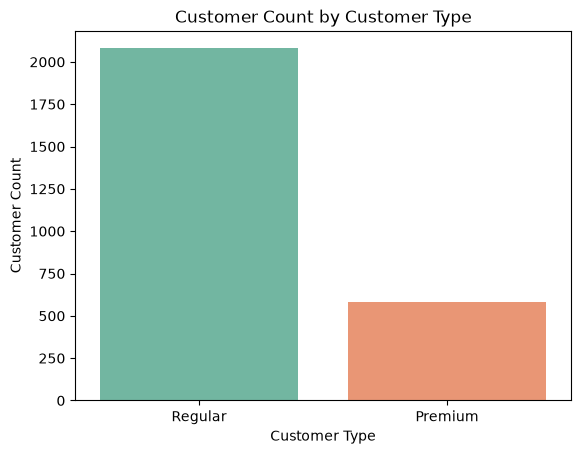

In [147]:
sns.barplot(data=premium_customers_df, x='customer_type', y='customer_count', hue='customer_type',palette='Set2',errorbar=None)
plt.title('Customer Count by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Customer Count')

In [58]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  case
   when c.age <18 then 'Minor'
   when c.age between 18 and 35 then 'Young Adult'
   when c.age between 36 and 55 then 'Adult'
   when c.age > 55 then 'Elderly'
 END as age_range, 
  CASE
  when c.is_premium = 1 THEN 'Premium'
  ELSE 'Regular'
  END as customer_type,
 AVG(t.revenue_usd) AS average_purchase_amount,COUNT(DISTINCT c.customer_id) AS customer_count

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY age_range,customer_type
ORDER BY age_range,customer_count DESC;"""

premium_customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

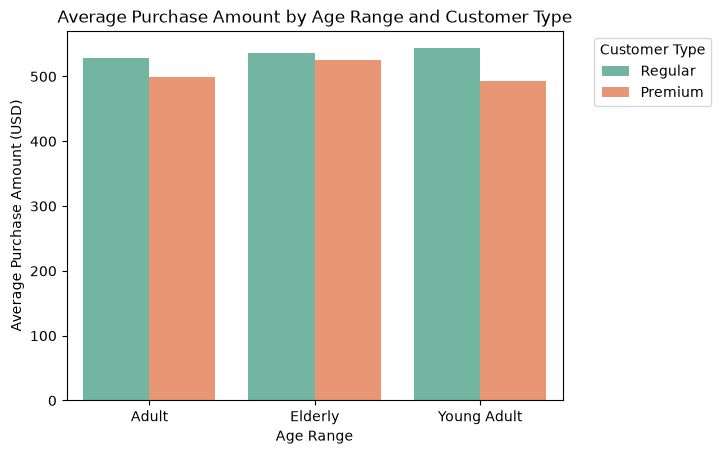

In [146]:
sns.barplot(data=premium_customers_df, x='age_range', y='average_purchase_amount', hue='customer_type',palette='Set2')
plt.title('Average Purchase Amount by Age Range and Customer Type')
plt.xlabel('Age Range')
plt.ylabel('Average Purchase Amount (USD)')
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')

In [77]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT
    c.customer_id,
    julianday('2024-12-31') - julianday(MAX(t.date)) AS recency_days,
    COUNT(t.transaction_id) AS frequency,
    SUM(t.revenue_usd) AS monetary,c.is_premium,c.email,c.registration_date
FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
WHERE t.status = 'completed'
GROUP BY c.customer_id
ORDER BY frequency DESC
LIMIT 10;"""

rfm_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [78]:
rfm_df.head(10)

,customer_id,recency_days,frequency,monetary,is_premium,email,registration_date
0,CUST01713,0.0,6684,3049669.48,1,elena.mueller1713@email.com,2020-05-16
1,CUST01068,0.0,3504,1970814.32,0,sara.rossi1068@email.com,2020-09-16
2,CUST05248,3.0,3224,1713106.56,0,david.harris5248@email.com,2021-04-17
3,CUST03000,4.0,2984,1692517.64,0,james.jackson3000@email.com,2021-01-21
4,CUST00785,0.0,2416,1532545.52,0,sara.rossi0785@email.com,2021-02-16
5,CUST01593,0.0,1700,920566.16,0,anna.dubois1593@email.com,2020-03-19
6,CUST04788,0.0,1524,882287.84,0,robert.jackson4788@email.com,2020-02-09
7,CUST03425,0.0,1292,726083.84,0,james.young3425@email.com,2021-11-18
8,CUST06388,3.0,1224,670359.16,0,daniel.johnson6388@email.com,2020-06-20
9,CUST07467,0.0,1216,611582.28,0,sara.harris7467@email.com,2021-09-15


Analysis of Shipping Cost and Profit per Country and Product

In [80]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT country, 
COUNT(DISTINCT customer_id) AS customer_count,
SUM(profit_usd) AS total_profit,
SUM(quantity) as Total_Units_Sold


FROM transactions t
WHERE status = 'completed'
GROUP BY country
ORDER BY customer_count DESC

LIMIT 10;"""

country_df = pd.read_sql_query(sql_query, conn)

conn.close()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'USA'),
  Text(1, 0, 'UK'),
  Text(2, 0, 'Germany'),
  Text(3, 0, 'France'),
  Text(4, 0, 'Canada'),
  Text(5, 0, 'Italy'),
  Text(6, 0, 'Spain'),
  Text(7, 0, 'Netherlands'),
  Text(8, 0, 'Australia'),
  Text(9, 0, 'Sweden')])

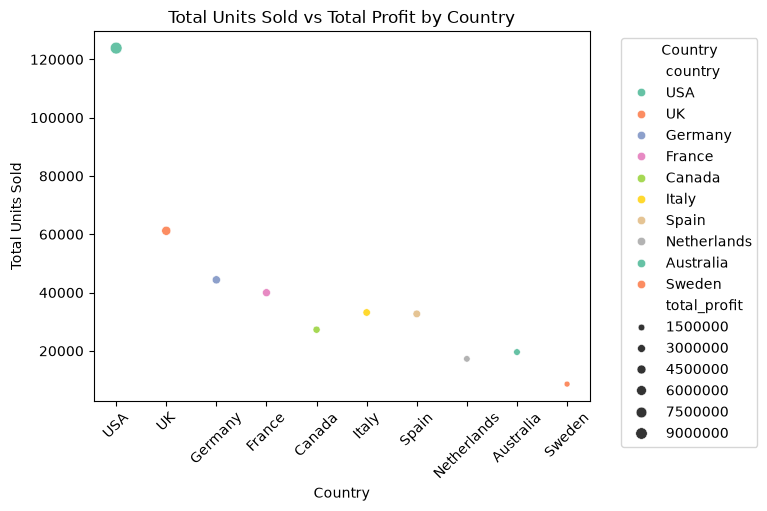

In [145]:
sns.scatterplot(data=country_df, x='country', y='Total_Units_Sold', size='total_profit', hue='country', palette='Set2')
plt.title('Total Units Sold vs Total Profit by Country')
plt.xlabel('Country')
plt.ylabel('Total Units Sold')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)


In [113]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT 
    strftime('%m', date) AS month,
    SUM(revenue_usd) AS total_revenue,
    SUM(profit_usd) AS total_profit,
    SUM(quantity) AS total_units_sold,
    COUNT(DISTINCT customer_id) AS customer_count

FROM transactions
WHERE status = 'completed'
GROUP BY month
ORDER BY month, total_revenue DESC
LIMIT 12;"""

best_months_df = pd.read_sql_query(sql_query, conn)

conn.close()

Text(0, 0.5, 'Total Revenue (USD)')

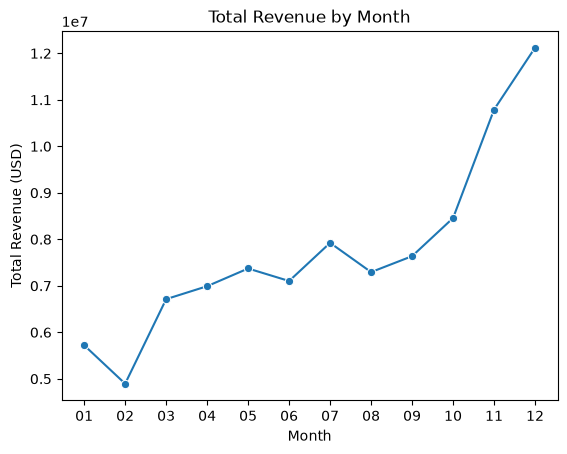

In [142]:
sns.lineplot(data=best_months_df, x='month', y='total_revenue', marker='o')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')

In [115]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """
SELECT 
    p.brand AS brand_name,
    SUM(t.revenue_usd) AS brand_revenue,
    SUM(t.quantity) AS brand_units,
    SUM(SUM(t.revenue_usd)) OVER () AS grand_total_revenue,
    ROUND(SUM(t.revenue_usd) * 100.0 / SUM(SUM(t.revenue_usd)) OVER (), 2) AS pct_of_total_revenue
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
    AND strftime('%m', t.date) IN ('10', '11', '12')
GROUP BY p.brand
ORDER BY brand_revenue DESC;
"""

brand_share_df = pd.read_sql_query(sql_query, conn)

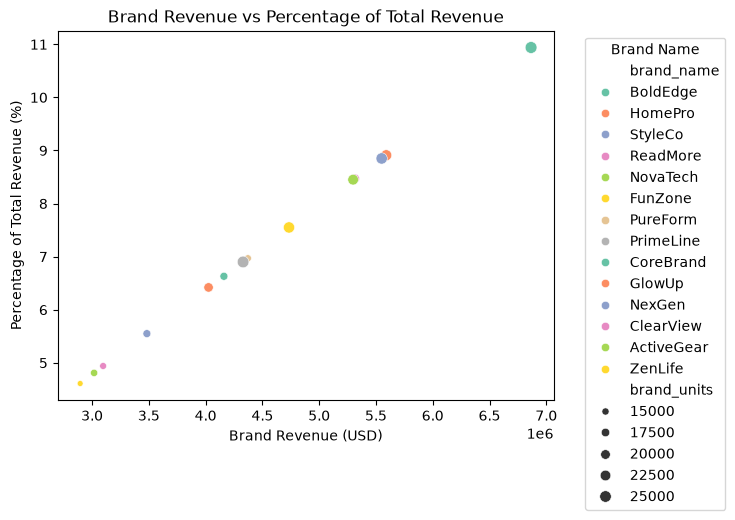

In [140]:
sns.scatterplot(data=brand_share_df, x='brand_revenue', y='pct_of_total_revenue', hue='brand_name', size='brand_units', palette='Set2')
plt.title('Brand Revenue vs Percentage of Total Revenue')
plt.xlabel('Brand Revenue (USD)')
plt.ylabel('Percentage of Total Revenue (%)')
plt.legend(title='Brand Name', bbox_to_anchor=(1.05, 1), loc='upper left')

In [132]:
sql_query = """
SELECT 
    CASE
        WHEN c.age < 18 THEN 'Minor'
        WHEN c.age BETWEEN 18 AND 35 THEN 'Young Adult'
        WHEN c.age BETWEEN 36 AND 55 THEN 'Adult'
        ELSE 'Elderly'
    END AS age_range,
    COUNT(DISTINCT c.customer_id) AS num_customers,
    SUM(t.revenue_usd) AS revenue,
    SUM(t.profit_usd) AS profit,
    SUM(t.quantity) AS units_sold
FROM transactions t
JOIN customers c ON t.customer_id = c.customer_id
JOIN products p ON t.product_id = p.product_id
WHERE p.brand = 'BoldEdge'
    
GROUP BY age_range
ORDER BY num_customers DESC;
"""

age_profile_df = pd.read_sql_query(sql_query, conn)

<Axes: xlabel='age_range', ylabel='units_sold'>

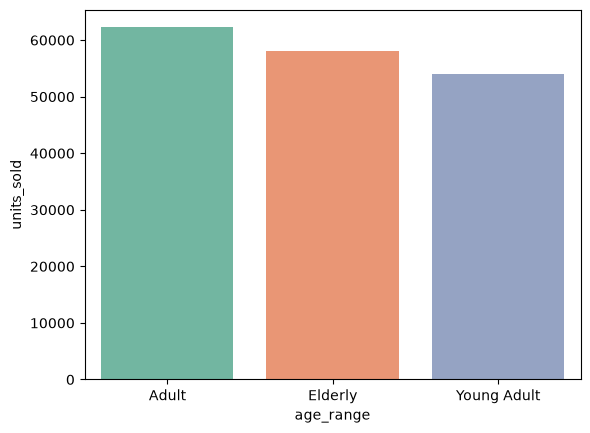

In [134]:
sns.barplot(data=age_profile_df, x='age_range', y='units_sold', hue='age_range', palette='Set2', errorbar=None)